# Lecture 10 — Neural Networks from Scratch

**Learning objectives**

By the end of this lecture you will be able to:

- State the perceptron learning rule and the perceptron convergence theorem, and explain why a single perceptron cannot solve XOR.
- Describe a multilayer perceptron (MLP), common activation functions and their derivatives, and the universal approximation theorem.
- Derive backpropagation using computational graphs and matrix calculus, including the softmax cross-entropy gradient.
- Implement a fully vectorised MLP in NumPy (forward pass, backward pass, mini-batch SGD) and verify it with numerical gradient checking.
- Explain why weight initialisation (Xavier/Glorot, He) matters and demonstrate it empirically.
- Implement SGD, momentum, RMSProp and Adam from scratch and compare them.
- Control overfitting with L2 regularisation and early stopping, and compare against `sklearn.neural_network.MLPClassifier`.

**Prerequisites**

- [`01_mathematical_foundations.ipynb`](01_mathematical_foundations.ipynb) (matrix calculus, gradient descent and conditioning).
- [`02_linear_regression.ipynb`](02_linear_regression.ipynb) (gradient descent, L2 regularisation) and [`03_logistic_regression_and_classification.ipynb`](03_logistic_regression_and_classification.ipynb) (logistic/softmax regression, cross-entropy).
- [`04_model_evaluation_and_selection.ipynb`](04_model_evaluation_and_selection.ipynb) (train/validation/test splits, overfitting, bias–variance).

**Contents**

1. The perceptron
2. The multilayer perceptron and activation functions
3. Universal approximation
4. The forward pass
5. Backpropagation: computational graphs and matrix calculus
6. A from-scratch NumPy MLP
7. Gradient checking
8. Training on `make_moons` and `load_digits`
9. Weight initialisation
10. Optimisers from scratch
11. Overfitting: L2 regularisation and early stopping
12. Comparison with scikit-learn's `MLPClassifier`
13. Pitfalls & practical tips
14. Exercises
15. Summary and further reading

In [1]:
%matplotlib inline
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)
rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=4, suppress=True)

def plot_boundary(predict, X, y, ax=None, title="", h=0.02):
    # Plot the decision regions of a classifier `predict: (n,2)->(n,)` on 2-D data.
    ax = ax or plt.gca()
    x0, x1 = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y0, y1 = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    Z = predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=15, edgecolor="k", linewidth=0.3)
    ax.set_title(title)

## 1. The perceptron

Rosenblatt's perceptron (1958) is the simplest neural "network": a single linear threshold unit. With labels $y \in \{-1, +1\}$ and input $\mathbf{x}\in\mathbb{R}^d$,

$$
\hat y = \operatorname{sign}(\mathbf{w}^\top \mathbf{x} + b).
$$

**Learning rule.** Cycle through the training points; whenever a point is misclassified, i.e. $y_i(\mathbf{w}^\top\mathbf{x}_i + b) \le 0$, update

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta\, y_i \mathbf{x}_i, \qquad b \leftarrow b + \eta\, y_i .
$$

This is exactly stochastic (sub)gradient descent on the *perceptron loss* $\ell(\mathbf{w}, b) = \max\bigl(0, -y(\mathbf{w}^\top\mathbf{x}+b)\bigr)$: on a mistake the subgradient is $-y\mathbf{x}$; otherwise it is $0$. Geometrically, each update rotates $\mathbf{w}$ towards $y_i\mathbf{x}_i$.

**Perceptron convergence theorem (Novikoff, 1962).** Absorb the bias into $\mathbf{w}$ by appending a constant feature. Suppose that $\|\mathbf{x}_i\| \le R$ for all $i$ and the data are *linearly separable with margin* $\gamma > 0$: there is a unit vector $\mathbf{w}^\star$ with $y_i\,\mathbf{w}^{\star\top}\mathbf{x}_i \ge \gamma$ for all $i$. Then the perceptron algorithm (started at $\mathbf{w}=\mathbf 0$) makes at most

$$
k \le \left(\frac{R}{\gamma}\right)^2
$$

mistakes, independent of the dimension and the number of samples.

*Proof sketch.* After $k$ mistakes, $\mathbf{w}_k^\top\mathbf{w}^\star \ge k\gamma$ (each update adds at least $\gamma$) and $\|\mathbf{w}_k\|^2 \le kR^2$ (each update adds at most $R^2$ because the cross term $2y_i\mathbf{w}^\top\mathbf{x}_i\le 0$ on a mistake). By Cauchy–Schwarz, $k\gamma \le \|\mathbf{w}_k\| \le \sqrt{k}R$, hence $k \le R^2/\gamma^2$. $\square$

If the data are **not** linearly separable the algorithm never converges: it cycles forever.

In [2]:
class PerceptronScratch:
    # Rosenblatt perceptron for labels in {-1, +1}.
    def __init__(self, lr=1.0, max_epochs=100):
        self.lr, self.max_epochs = lr, max_epochs

    def fit(self, X, y):
        n, d = X.shape
        self.w, self.b = np.zeros(d), 0.0
        self.mistakes_per_epoch = []
        for epoch in range(self.max_epochs):
            mistakes = 0
            for i in range(n):
                if y[i] * (X[i] @ self.w + self.b) <= 0:   # misclassified (or on the boundary)
                    self.w += self.lr * y[i] * X[i]
                    self.b += self.lr * y[i]
                    mistakes += 1
            self.mistakes_per_epoch.append(mistakes)
            if mistakes == 0:                              # converged: a full pass without error
                break
        return self

    def predict(self, X):
        return np.where(X @ self.w + self.b >= 0, 1, -1)

# Linearly separable data
Xs, ys01 = make_blobs(n_samples=200, centers=[(-2, -2), (2, 2)], cluster_std=1.0, random_state=42)
ys = 2 * ys01 - 1
p = PerceptronScratch().fit(Xs, ys)
print("epochs until convergence:", len(p.mistakes_per_epoch))
print("total mistakes:", sum(p.mistakes_per_epoch))
print("training accuracy (scratch):", (p.predict(Xs) == ys).mean())

sk = SkPerceptron(random_state=42).fit(Xs, ys)
print("training accuracy (sklearn):", sk.score(Xs, ys))

# Empirical check of the Novikoff bound, using the max-margin direction from the data
Xa = np.c_[Xs, np.ones(len(Xs))]              # absorb bias
R = np.linalg.norm(Xa, axis=1).max()
wa = np.r_[p.w, p.b]; wa /= np.linalg.norm(wa)
gamma = (ys * (Xa @ wa)).min()                  # margin achieved by the learned separator
print(f"R = {R:.2f}, margin of learned separator = {gamma:.3f}, bound (R/gamma)^2 = {(R/gamma)**2:.0f}")

epochs until convergence: 2
total mistakes: 3
training accuracy (scratch): 1.0
training accuracy (sklearn): 1.0
R = 6.45, margin of learned separator = 0.135, bound (R/gamma)^2 = 2283


The bound uses the *best* achievable margin $\gamma$; plugging in the margin of the separator we found gives a (valid but loose) upper bound because that margin is at most the optimal one. Now the classic failure: **XOR** is not linearly separable, so no single linear threshold unit can represent it (Minsky & Papert, 1969).

mistakes per epoch (last 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
XOR accuracy: 0.5


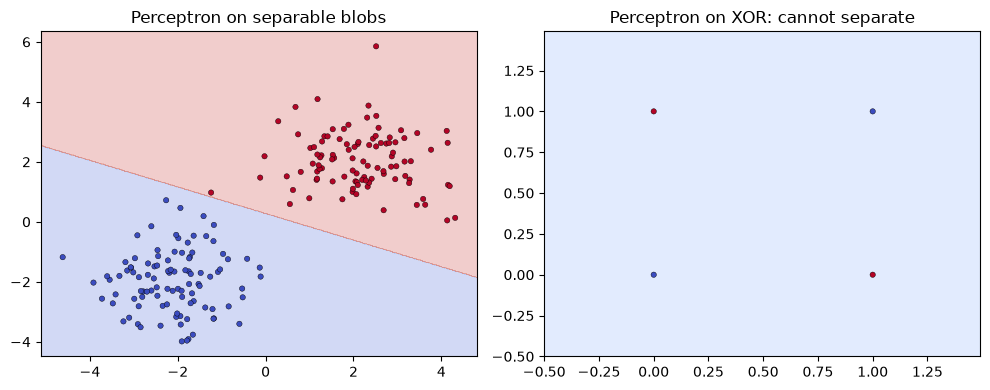

In [3]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([-1, 1, 1, -1])
p_xor = PerceptronScratch(max_epochs=50).fit(X_xor, y_xor)
print("mistakes per epoch (last 10):", p_xor.mistakes_per_epoch[-10:])
print("XOR accuracy:", (p_xor.predict(X_xor) == y_xor).mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_boundary(p.predict, Xs, ys, ax=axes[0], title="Perceptron on separable blobs")
plot_boundary(p_xor.predict, X_xor, y_xor, ax=axes[1], title="Perceptron on XOR: cannot separate", h=0.01)
plt.tight_layout(); plt.show()

## 2. The multilayer perceptron and activation functions

The fix for XOR is to compose several layers of units with **nonlinear** activations. An $L$-layer MLP computes

$$
\mathbf{a}^{(0)} = \mathbf{x},\qquad
\mathbf{z}^{(\ell)} = W^{(\ell)}\mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)},\qquad
\mathbf{a}^{(\ell)} = \phi\bigl(\mathbf{z}^{(\ell)}\bigr),\quad \ell = 1,\dots,L-1,
$$

and an output layer $\mathbf{z}^{(L)} = W^{(L)}\mathbf{a}^{(L-1)} + \mathbf{b}^{(L)}$ followed by a task-specific link (softmax for classification, identity for regression). Without the nonlinearity $\phi$, the composition collapses to a single affine map $W^{(L)}\cdots W^{(1)}\mathbf{x} + \mathbf{c}$ — no more expressive than a linear model.

XOR by hand: with two hidden ReLU units $h_1 = \max(0, x_1 + x_2)$, $h_2 = \max(0, x_1 + x_2 - 1)$ and output $h_1 - 2h_2$ we get $0, 1, 1, 0$ on the four inputs.

**Common activations and their derivatives**

| Name | $\phi(z)$ | $\phi'(z)$ | Range | Notes |
|---|---|---|---|---|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z)) \le \tfrac14$ | $(0,1)$ | saturates; not zero-centred |
| Tanh | $\tanh z$ | $1 - \tanh^2 z \le 1$ | $(-1,1)$ | zero-centred; still saturates; $\tanh z = 2\sigma(2z)-1$ |
| ReLU | $\max(0,z)$ | $\mathbb{1}[z>0]$ | $[0,\infty)$ | no saturation for $z>0$; cheap; "dead" units possible |
| Leaky ReLU | $\max(\alpha z, z)$ | $1$ or $\alpha$ | $\mathbb{R}$ | avoids dead units |

The derivative bound matters for **vanishing gradients**: backpropagation multiplies by $\phi'(z)$ once per layer, so with sigmoid the gradient shrinks by at least a factor 4 per layer.

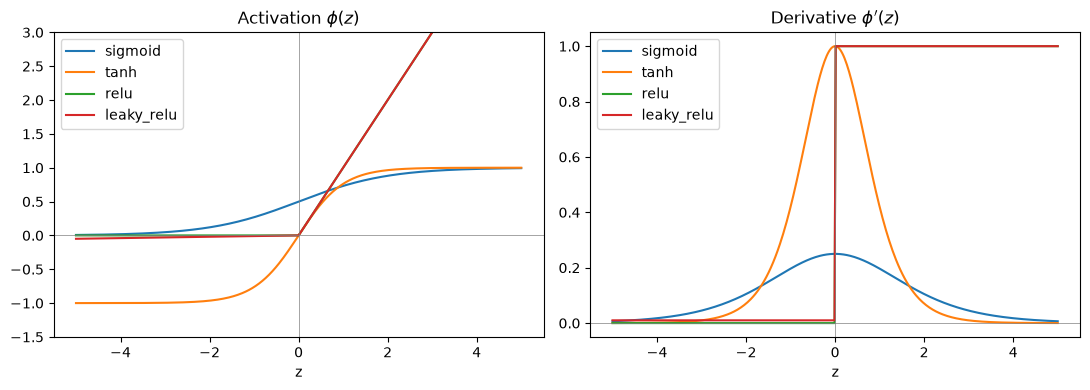

hand-crafted MLP on XOR -> [0. 1. 1. 0.]


In [4]:
# Activation functions and their derivatives (used by the MLP later)
def sigmoid(z):
    # numerically stable logistic function
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1 + ez)
    return out

ACTIVATIONS = {
    "sigmoid": (sigmoid,                 lambda z: sigmoid(z) * (1 - sigmoid(z))),
    "tanh":    (np.tanh,                 lambda z: 1 - np.tanh(z) ** 2),
    "relu":    (lambda z: np.maximum(0, z), lambda z: (z > 0).astype(float)),
    "leaky_relu": (lambda z: np.where(z > 0, z, 0.01 * z), lambda z: np.where(z > 0, 1.0, 0.01)),
}

z = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, (f, df) in ACTIVATIONS.items():
    axes[0].plot(z, f(z), label=name)
    axes[1].plot(z, df(z), label=name)
axes[0].set_title("Activation $\\phi(z)$"); axes[1].set_title("Derivative $\\phi'(z)$")
for ax in axes:
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5); ax.legend(); ax.set_xlabel("z")
axes[0].set_ylim(-1.5, 3)
plt.tight_layout(); plt.show()

# Hand-built XOR network from the text
h = np.maximum(0, X_xor @ np.array([[1, 1], [1, 1]]) + np.array([0, -1]))
print("hand-crafted MLP on XOR ->", h @ np.array([1, -2]))

## 3. Universal approximation

**Theorem (Cybenko 1989; Hornik 1991; Leshno et al. 1993).** Let $\phi$ be any continuous function that is not a polynomial. For every continuous $f: K \to \mathbb{R}$ on a compact set $K\subset\mathbb{R}^d$ and every $\varepsilon > 0$ there exist $N$ and parameters $\{v_j, \mathbf{w}_j, b_j\}_{j=1}^N$ such that

$$
\sup_{\mathbf{x}\in K} \Bigl| f(\mathbf{x}) - \sum_{j=1}^N v_j\, \phi(\mathbf{w}_j^\top \mathbf{x} + b_j)\Bigr| < \varepsilon .
$$

So a network with **one hidden layer** is already a universal approximator. Important caveats:

- It is an *existence* result: it says nothing about how to *find* the weights (optimisation) or how well they *generalise* from finite data (statistics).
- The required width $N$ can grow exponentially with $d$ for some functions. Depth can be exponentially more efficient than width for certain function classes (e.g. Telgarsky, 2016), which is one theoretical motivation for *deep* networks.

Intuition for ReLU in 1-D: $\sum_j v_j \max(0, x - t_j)$ is a piecewise-linear spline with knots $t_j$; with enough knots it fits any continuous curve. We check this below with a least-squares fit of the output weights on random ReLU features (a "random features" model).

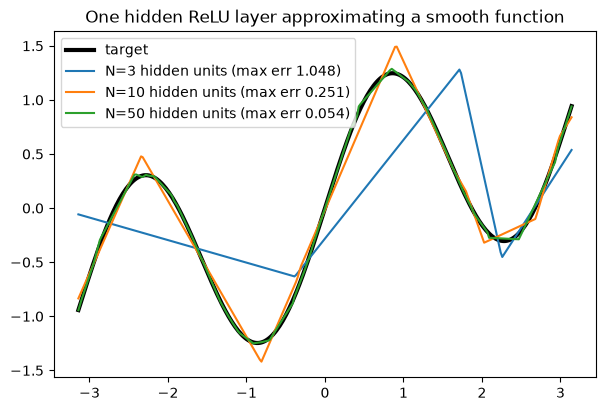

In [5]:
x = np.linspace(-np.pi, np.pi, 300)[:, None]
f_true = np.sin(2 * x).ravel() + 0.3 * x.ravel()

fig, ax = plt.subplots()
ax.plot(x, f_true, "k", lw=3, label="target")
for N in [3, 10, 50]:
    knots = rng.uniform(-np.pi, np.pi, size=N)
    signs = rng.choice([-1, 1], size=N)
    H = np.maximum(0, signs * (x - knots))          # (300, N) hidden ReLU activations
    H = np.c_[H, np.ones(len(x))]                   # output bias
    v, *_ = np.linalg.lstsq(H, f_true, rcond=None)  # fit output layer only
    err = np.abs(H @ v - f_true).max()
    ax.plot(x, H @ v, label=f"N={N} hidden units (max err {err:.3f})")
ax.legend(); ax.set_title("One hidden ReLU layer approximating a smooth function")
plt.show()

## 4. The forward pass (vectorised)

For efficiency we process a **mini-batch** of $m$ examples at once, stored as rows of $X\in\mathbb{R}^{m\times d}$. With the row convention, layer $\ell$ has weights $W^{(\ell)}\in\mathbb{R}^{n_{\ell-1}\times n_\ell}$ and bias $\mathbf{b}^{(\ell)}\in\mathbb{R}^{1\times n_\ell}$ (broadcast over rows):

$$
Z^{(\ell)} = A^{(\ell-1)} W^{(\ell)} + \mathbf{1}\mathbf{b}^{(\ell)},\qquad A^{(\ell)} = \phi(Z^{(\ell)}),\qquad A^{(0)} = X .
$$

For $K$-class classification the last layer produces **logits** $Z^{(L)}\in\mathbb{R}^{m\times K}$, turned into probabilities by the softmax

$$
P_{ik} = \frac{\exp(Z^{(L)}_{ik})}{\sum_{k'}\exp(Z^{(L)}_{ik'})},
$$

and the loss is the mean **cross-entropy** (negative log-likelihood of a categorical model), plus an optional L2 penalty:

$$
\mathcal{L} = -\frac{1}{m}\sum_{i=1}^m \log P_{i, y_i} \;+\; \frac{\lambda}{2}\sum_{\ell}\|W^{(\ell)}\|_F^2 .
$$

**Numerical stability.** Compute softmax with $Z - \max_k Z_{ik}$ subtracted row-wise (softmax is shift-invariant), and compute $\log P$ as $Z_{ik} - \operatorname{logsumexp}_k(Z_{i\cdot})$ to avoid $\log 0$.

**Cost.** A forward pass costs $O\bigl(m\sum_\ell n_{\ell-1}n_\ell\bigr)$ flops — dominated by the matrix products — and must store all $Z^{(\ell)}, A^{(\ell)}$ for the backward pass, i.e. $O(m\sum_\ell n_\ell)$ memory.

## 5. Backpropagation: computational graphs and matrix calculus

### 5.1 Computational graphs and the chain rule

Any differentiable computation can be written as a directed acyclic graph whose nodes are elementary operations. For a scalar output $\mathcal L$ and a node $u$ with children $v_1,\dots,v_k$ (nodes that consume $u$), the multivariate chain rule gives

$$
\frac{\partial\mathcal L}{\partial u} = \sum_{j=1}^k \frac{\partial \mathcal L}{\partial v_j}\,\frac{\partial v_j}{\partial u}.
$$

**Reverse-mode automatic differentiation** (backpropagation) evaluates this by visiting nodes in reverse topological order, propagating the "upstream gradient" $\bar u := \partial\mathcal L/\partial u$ (the *adjoint*). Each node only needs a local rule mapping output adjoint to input adjoints. The whole gradient costs a small constant times one forward pass — independent of the number of parameters — which is why it scales to millions of weights (forward-mode would need one pass per input dimension).

A tiny example: $\mathcal{L} = (w x + b - y)^2$. Graph: $u = wx$, $z = u + b$, $r = z - y$, $\mathcal L = r^2$. Backward: $\bar r = 2r$, $\bar z = \bar r$, $\bar b = \bar z$, $\bar u = \bar z$, $\bar w = \bar u\,x$.

### 5.2 Local rules for matrix operations

We use the convention that $\bar X = \partial\mathcal L/\partial X$ has the same shape as $X$.

- **Affine map** $Z = AW + \mathbf 1\mathbf b$. Since $Z_{ij} = \sum_k A_{ik}W_{kj} + b_j$,
  $$\bar W = A^\top \bar Z,\qquad \bar A = \bar Z W^\top,\qquad \bar{\mathbf b} = \mathbf 1^\top \bar Z \;(\text{sum over rows}).$$
  (Check shapes: $\bar W$ is $(n_{\ell-1}\times m)(m\times n_\ell)$. Shape-matching is a reliable way to remember these.)
- **Elementwise activation** $A = \phi(Z)$: the Jacobian is diagonal, so $\bar Z = \bar A \odot \phi'(Z)$.
- **Softmax + cross-entropy.** For one example with logits $\mathbf z$, $p_k = e^{z_k}/\sum_j e^{z_j}$ and $\ell = -\log p_y = -z_y + \log\sum_j e^{z_j}$. Then
  $$\frac{\partial \ell}{\partial z_k} = -\mathbb 1[k=y] + \frac{e^{z_k}}{\sum_j e^{z_j}} = p_k - \mathbb 1[k=y].$$
  In matrix form for the batch mean: $\bar Z^{(L)} = \frac{1}{m}(P - Y)$ with $Y$ the one-hot label matrix. The elegant form is no accident: softmax/cross-entropy is the canonical link of the categorical exponential family (the same as in logistic regression).
- **L2 penalty** $\frac\lambda2\|W\|_F^2$ adds $\lambda W$ to $\bar W$.

### 5.3 The backpropagation algorithm

Starting from $\Delta^{(L)} := \bar Z^{(L)} = \frac1m(P-Y)$, for $\ell = L, L-1, \dots, 1$:

$$
\bar W^{(\ell)} = A^{(\ell-1)\top}\Delta^{(\ell)} + \lambda W^{(\ell)},\qquad
\bar{\mathbf b}^{(\ell)} = \mathbf 1^\top\Delta^{(\ell)},\qquad
\Delta^{(\ell-1)} = \bigl(\Delta^{(\ell)}W^{(\ell)\top}\bigr)\odot\phi'\bigl(Z^{(\ell-1)}\bigr).
$$

Unrolling the recursion, $\Delta^{(\ell)}$ contains a product of $L-\ell$ weight matrices and derivative factors — the origin of **vanishing** (factors $<1$) and **exploding** (factors $>1$) gradients, and the reason initialisation (Section 9) matters.

In [6]:
# The scalar example from 5.1, verified numerically
w_, x_, b_, y_ = 1.5, 2.0, -0.5, 1.0
u = w_ * x_; z_ = u + b_; r = z_ - y_; L_ = r ** 2          # forward
r_bar = 2 * r; z_bar = r_bar; b_bar = z_bar; u_bar = z_bar; w_bar = u_bar * x_   # backward
eps = 1e-6
num_w = (((w_ + eps) * x_ + b_ - y_) ** 2 - ((w_ - eps) * x_ + b_ - y_) ** 2) / (2 * eps)
print(f"dL/dw backprop = {w_bar:.6f}, numerical = {num_w:.6f}; dL/db = {b_bar:.6f}")

dL/dw backprop = 6.000000, numerical = 6.000000; dL/db = 3.000000


## 6. A from-scratch NumPy MLP

We now translate Sections 4–5 directly into code. Design choices:

- Parameters are stored in two lists `W[l]`, `b[l]`; the forward pass caches every $Z^{(\ell)}$ and $A^{(\ell)}$.
- `loss_and_grads` returns the loss and gradients in the same structure as the parameters, so an optimiser can treat them as a flat list of arrays.
- Initialisation schemes are selectable (`"he"`, `"xavier"`, `"small"`) — see Section 9.

In [7]:
def one_hot(y, K):
    Y = np.zeros((len(y), K)); Y[np.arange(len(y)), y] = 1.0
    return Y

def log_softmax(Z):
    Zs = Z - Z.max(axis=1, keepdims=True)                   # shift for stability
    return Zs - np.log(np.exp(Zs).sum(axis=1, keepdims=True))

class MLP:
    # Fully connected network: hidden layers with activation `act`, softmax output.
    def __init__(self, sizes, act="relu", init="he", l2=0.0, seed=0, dtype=np.float64):
        self.sizes, self.l2 = sizes, l2
        self.phi, self.dphi = ACTIVATIONS[act]
        g = np.random.default_rng(seed)
        self.W, self.b = [], []
        for n_in, n_out in zip(sizes[:-1], sizes[1:]):
            if init == "he":          # Var = 2 / fan_in   (for ReLU)
                std = np.sqrt(2.0 / n_in)
            elif init == "xavier":    # Var = 2 / (fan_in + fan_out)   (for tanh / sigmoid)
                std = np.sqrt(2.0 / (n_in + n_out))
            elif init == "small":     # a naive choice
                std = 0.01
            elif init == "large":
                std = 1.0
            else:
                raise ValueError(init)
            self.W.append((g.standard_normal((n_in, n_out)) * std).astype(dtype))
            self.b.append(np.zeros((1, n_out), dtype=dtype))

    @property
    def params(self):
        return self.W + self.b

    def forward(self, X):
        # Returns logits and the cache of (Z, A) needed by backprop.
        A = X
        cache = {"A": [X], "Z": []}
        L = len(self.W)
        for l in range(L):
            Z = A @ self.W[l] + self.b[l]
            A = Z if l == L - 1 else self.phi(Z)     # no activation on the output logits
            cache["Z"].append(Z); cache["A"].append(A)
        return Z, cache

    def loss(self, X, y, penalty=True):
        # mean cross-entropy, plus the L2 penalty unless penalty=False
        Z, _ = self.forward(X)
        data = -log_softmax(Z)[np.arange(len(y)), y].mean()
        return data + (0.5 * self.l2 * sum((W ** 2).sum() for W in self.W) if penalty else 0.0)

    def loss_and_grads(self, X, y):
        m = len(y)
        Z, cache = self.forward(X)
        logP = log_softmax(Z)
        loss = -logP[np.arange(m), y].mean() + 0.5 * self.l2 * sum((W ** 2).sum() for W in self.W)

        dW, db = [None] * len(self.W), [None] * len(self.W)
        Delta = (np.exp(logP) - one_hot(y, Z.shape[1])) / m          # dL/dZ^(L) = (P - Y)/m
        for l in reversed(range(len(self.W))):
            A_prev = cache["A"][l]
            dW[l] = A_prev.T @ Delta + self.l2 * self.W[l]           # dL/dW = A^T Delta + lambda W
            db[l] = Delta.sum(axis=0, keepdims=True)                 # dL/db = column sums
            if l > 0:                                                # propagate to previous layer
                Delta = (Delta @ self.W[l].T) * self.dphi(cache["Z"][l - 1])
        return loss, dW + db

    def predict_proba(self, X):
        return np.exp(log_softmax(self.forward(X)[0]))

    def predict(self, X):
        return self.forward(X)[0].argmax(axis=1)

    def score(self, X, y):
        return (self.predict(X) == y).mean()

net = MLP([2, 16, 16, 2])
print("parameter shapes:", [p.shape for p in net.params])
print("number of parameters:", sum(p.size for p in net.params))
print("initial loss (should be of order log 2 = 0.693):", round(net.loss(*make_moons(100, noise=0.2, random_state=0)), 4))

parameter shapes: [(2, 16), (16, 16), (16, 2), (1, 16), (1, 16), (1, 2)]
number of parameters: 354


initial loss (should be of order log 2 = 0.693): 0.8818


**Sanity check on the initial loss.** With small random weights the logits are near zero, so $P \approx 1/K$ and $\mathcal L \approx \log K$. A very different initial loss is a red flag (e.g. wrong scale or a bug in the softmax).

Next, the optimiser. Plain mini-batch SGD is $\theta \leftarrow \theta - \eta\,\nabla_\theta \mathcal{L}_{\mathcal B}$ where $\mathcal B$ is a random mini-batch; $\nabla\mathcal L_{\mathcal B}$ is an unbiased estimate of the full-batch gradient with variance $\propto 1/|\mathcal B|$. We write the optimisers as small classes with a `step(params, grads)` method that updates arrays **in place**, and a generic training loop.

In [8]:
class SGD:
    def __init__(self, lr=0.1):
        self.lr = lr
    def step(self, params, grads):
        for p, g in zip(params, grads):
            p -= self.lr * g

def train(model, opt, X, y, X_val=None, y_val=None, epochs=100, batch_size=32, seed=0,
          patience=None, verbose=False):
    # Mini-batch training loop with optional early stopping on validation loss.
    g = np.random.default_rng(seed)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best = (np.inf, None, 0)                       # (best val loss, params snapshot, epoch)
    for epoch in range(epochs):
        idx = g.permutation(len(y))                # reshuffle every epoch
        for start in range(0, len(y), batch_size):
            batch = idx[start:start + batch_size]
            _, grads = model.loss_and_grads(X[batch], y[batch])
            opt.step(model.params, grads)
        # we record the *data* loss (cross-entropy without the L2 penalty) for monitoring
        hist["train_loss"].append(model.loss(X, y, penalty=False)); hist["train_acc"].append(model.score(X, y))
        if X_val is not None:
            vl = model.loss(X_val, y_val, penalty=False)
            hist["val_loss"].append(vl); hist["val_acc"].append(model.score(X_val, y_val))
            if patience is not None:
                if vl < best[0]:
                    best = (vl, [p.copy() for p in model.params], epoch)
                elif epoch - best[2] >= patience:  # no improvement for `patience` epochs
                    for p, q in zip(model.params, best[1]):
                        p[...] = q                 # restore the best weights
                    hist["stopped_epoch"], hist["best_epoch"] = epoch, best[2]
                    break
        if verbose and epoch % 20 == 0:
            print(f"epoch {epoch:3d}  loss {hist['train_loss'][-1]:.4f}")
    return hist

## 7. Gradient checking

Backprop code is easy to get subtly wrong (a missing transpose, a forgotten $1/m$) while still "sort of" training. The standard defence is to compare the analytic gradient with the **central finite difference**

$$
\frac{\partial\mathcal L}{\partial\theta_j} \approx \frac{\mathcal L(\theta + \varepsilon\mathbf e_j) - \mathcal L(\theta - \varepsilon\mathbf e_j)}{2\varepsilon},
$$

whose truncation error is $O(\varepsilon^2)$ (the one-sided difference is only $O(\varepsilon)$). We report the **relative error**

$$
\text{rel. error} = \frac{\|g_{\text{analytic}} - g_{\text{numeric}}\|_2}{\|g_{\text{analytic}}\|_2 + \|g_{\text{numeric}}\|_2}.
$$

Rules of thumb in float64 with $\varepsilon\approx10^{-5}$: $<10^{-7}$ excellent; $10^{-5}$ suspicious; $>10^{-3}$ almost certainly a bug. Use a smooth activation (tanh) or avoid kinks for ReLU, use float64, a tiny network, and turn off stochastic parts (dropout).

In [9]:
def numerical_grads(model, X, y, eps=1e-5):
    grads = []
    for p in model.params:
        g = np.zeros_like(p)
        it = np.nditer(p, flags=["multi_index"])
        for _ in it:
            i = it.multi_index
            old = p[i]
            p[i] = old + eps; lp = model.loss(X, y)
            p[i] = old - eps; lm = model.loss(X, y)
            p[i] = old
            g[i] = (lp - lm) / (2 * eps)
        grads.append(g)
    return grads

def rel_error(a, b):
    a = np.concatenate([x.ravel() for x in a]); b = np.concatenate([x.ravel() for x in b])
    return np.linalg.norm(a - b) / (np.linalg.norm(a) + np.linalg.norm(b))

Xg = rng.standard_normal((20, 5)); yg = rng.integers(0, 3, size=20)
for act in ["tanh", "sigmoid", "relu"]:
    gnet = MLP([5, 7, 6, 3], act=act, init="xavier", l2=0.1, seed=1)
    _, g_an = gnet.loss_and_grads(Xg, yg)
    g_num = numerical_grads(gnet, Xg, yg)
    print(f"{act:8s} relative error = {rel_error(g_an, g_num):.2e}")

# Demonstrate that the check catches a bug: forget the 1/m factor in the bias gradient
class BuggyMLP(MLP):
    def loss_and_grads(self, X, y):
        loss, grads = super().loss_and_grads(X, y)
        nL = len(self.W)
        grads[nL] = grads[nL] * len(y)             # bias of first layer scaled by m
        return loss, grads
bnet = BuggyMLP([5, 7, 6, 3], act="tanh", init="xavier", seed=1)
print(f"buggy    relative error = {rel_error(bnet.loss_and_grads(Xg, yg)[1], numerical_grads(bnet, Xg, yg)):.2e}")

tanh     relative error = 1.42e-10
sigmoid  relative error = 9.96e-11
relu     relative error = 1.20e-10
buggy    relative error = 6.80e-01


## 8. Training on `make_moons` and `load_digits`

### 8.1 Two moons

The two-moons dataset is not linearly separable, so logistic regression (or a perceptron) fails, but a small MLP learns a curved boundary.

trained in 0.2s; train acc 0.952, test acc 0.944


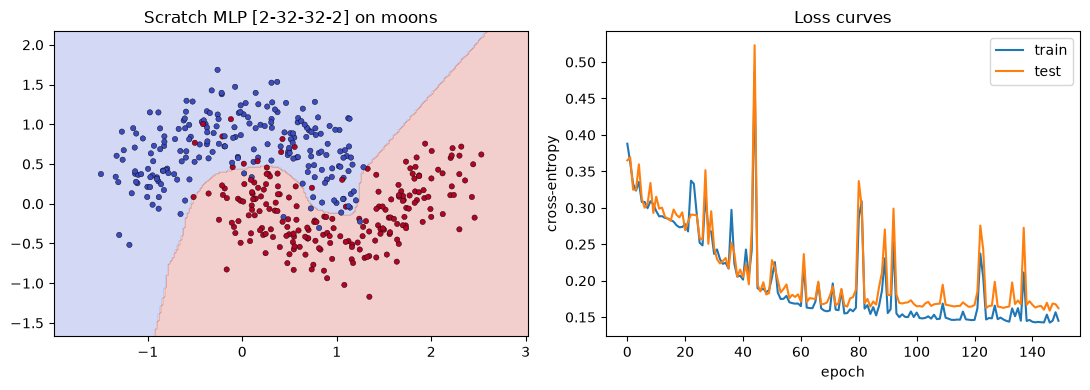

In [10]:
Xm, ym = make_moons(n_samples=600, noise=0.25, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=42, stratify=ym)

t0 = time.time()
moon_net = MLP([2, 32, 32, 2], act="relu", init="he", seed=0)
h_moon = train(moon_net, SGD(lr=0.1), Xm_tr, ym_tr, Xm_te, ym_te, epochs=150, batch_size=32)
print(f"trained in {time.time() - t0:.1f}s; train acc {moon_net.score(Xm_tr, ym_tr):.3f}, test acc {moon_net.score(Xm_te, ym_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_boundary(moon_net.predict, Xm_tr, ym_tr, ax=axes[0], title="Scratch MLP [2-32-32-2] on moons")
axes[1].plot(h_moon["train_loss"], label="train"); axes[1].plot(h_moon["val_loss"], label="test")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cross-entropy"); axes[1].legend(); axes[1].set_title("Loss curves")
plt.tight_layout(); plt.show()

### 8.2 Handwritten digits

`load_digits` contains 1797 grey-scale $8\times8$ images (64 features, 10 classes). We standardise features using statistics from the **training** split only, then train a $64\to64\to10$ network.

train/val/test sizes: 1077 270 450


trained in 0.3s; val acc 0.974, test acc 0.964


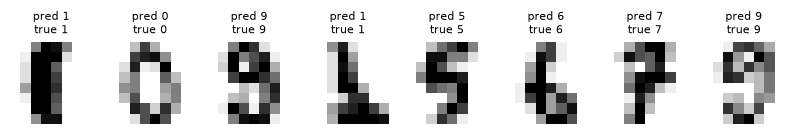

In [11]:
digits = load_digits()
Xd, yd = digits.data, digits.target
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, random_state=42, stratify=yd)
Xd_tr, Xd_val, yd_tr, yd_val = train_test_split(Xd_tr, yd_tr, test_size=0.2, random_state=42, stratify=yd_tr)
scaler = StandardScaler().fit(Xd_tr)
Xd_tr_s, Xd_val_s, Xd_te_s = scaler.transform(Xd_tr), scaler.transform(Xd_val), scaler.transform(Xd_te)
print("train/val/test sizes:", len(yd_tr), len(yd_val), len(yd_te))

t0 = time.time()
dig_net = MLP([64, 64, 10], act="relu", init="he", seed=0)
h_dig = train(dig_net, SGD(lr=0.05), Xd_tr_s, yd_tr, Xd_val_s, yd_val, epochs=60, batch_size=32)
print(f"trained in {time.time() - t0:.1f}s; val acc {h_dig['val_acc'][-1]:.3f}, test acc {dig_net.score(Xd_te_s, yd_te):.3f}")

# Show a few test predictions
fig, axes = plt.subplots(1, 8, figsize=(10, 1.8))
pred = dig_net.predict(Xd_te_s)
for ax, i in zip(axes, range(8)):
    ax.imshow(Xd_te[i].reshape(8, 8), cmap="gray_r"); ax.axis("off")
    ax.set_title(f"pred {pred[i]}\ntrue {yd_te[i]}", fontsize=8, color="k" if pred[i] == yd_te[i] else "r")
plt.show()

## 9. Weight initialisation

**Why not zeros?** If all weights in a layer are equal, all hidden units compute the same function and receive the same gradient — the **symmetry** is never broken. Random initialisation is required; the question is the *scale*.

**Variance propagation.** Consider $z_j = \sum_{i=1}^{n_{\text{in}}} W_{ij}a_i$ with i.i.d. zero-mean weights of variance $\sigma_W^2$, independent of the inputs. Then

$$
\operatorname{Var}(z_j) = n_{\text{in}}\,\sigma_W^2\,\mathbb E[a_i^2].
$$

- For a **linear/tanh** regime ($\phi(z)\approx z$ near 0), $\mathbb{E}[a^2]\approx\operatorname{Var}(z_{\text{prev}})$, so keeping the forward variance constant needs $\sigma_W^2 = 1/n_{\text{in}}$; the same argument for the backward pass gives $1/n_{\text{out}}$. **Xavier/Glorot** (2010) compromises: $\sigma_W^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}$.
- For **ReLU**, half the pre-activations are zeroed, so $\mathbb{E}[a^2] = \tfrac12\operatorname{Var}(z_{\text{prev}})$ (for symmetric $z$), giving **He/Kaiming** (2015): $\sigma_W^2 = \frac{2}{n_{\text{in}}}$.

Too small a scale makes activations (and gradients) shrink geometrically with depth; too large makes them explode or saturate. We verify this with a 10-layer ReLU network.

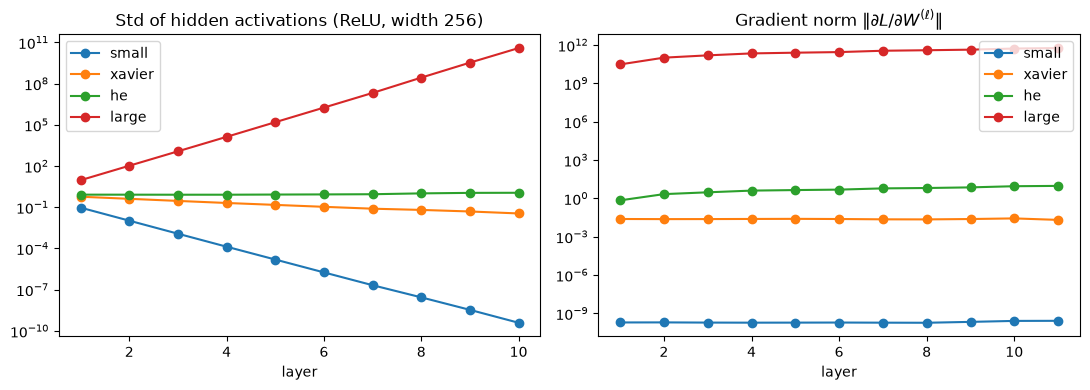

In [12]:
X_probe = rng.standard_normal((1000, 256))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for init in ["small", "xavier", "he", "large"]:
    deep = MLP([256] * 11 + [10], act="relu", init=init, seed=0)
    _, cache = deep.forward(X_probe)
    stds = [A.std() for A in cache["A"][1:-1]]     # hidden activations
    axes[0].semilogy(range(1, len(stds) + 1), stds, "o-", label=init)
    # gradient norms per layer for a random labelling
    _, grads = deep.loss_and_grads(X_probe, rng.integers(0, 10, 1000))
    gnorm = [np.linalg.norm(g) for g in grads[:len(deep.W)]]
    axes[1].semilogy(range(1, len(gnorm) + 1), gnorm, "o-", label=init)
axes[0].set_title("Std of hidden activations (ReLU, width 256)"); axes[0].set_xlabel("layer")
axes[1].set_title("Gradient norm $\\|\\partial L/\\partial W^{(\\ell)}\\|$"); axes[1].set_xlabel("layer")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

With He initialisation the activation scale is roughly constant across layers; with $\sigma=0.01$ it collapses by a factor $\approx\sqrt{256\cdot 10^{-4}/2}\approx 0.11$ per layer, and with $\sigma = 1$ it explodes by $\approx\sqrt{128}\approx 11$ per layer. Xavier sits slightly below He for ReLU (it is designed for tanh). Now the effect on *training* a moderately deep network:

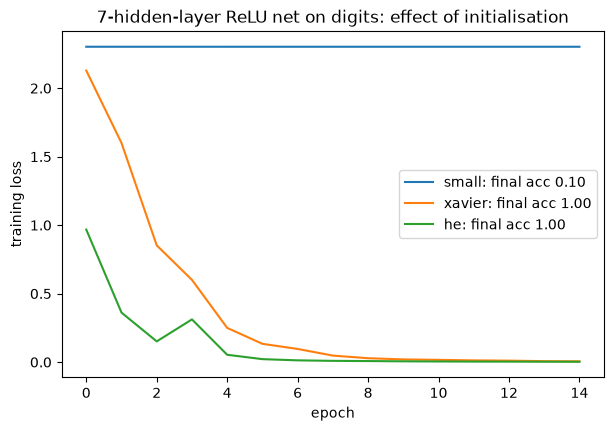

In [13]:
fig, ax = plt.subplots()
for init in ["small", "xavier", "he"]:
    net_i = MLP([64] + [64] * 6 + [10], act="relu", init=init, seed=0)
    h_i = train(net_i, SGD(lr=0.05), Xd_tr_s, yd_tr, epochs=15, batch_size=32)
    ax.plot(h_i["train_loss"], label=f"{init}: final acc {h_i['train_acc'][-1]:.2f}")
ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.set_title("7-hidden-layer ReLU net on digits: effect of initialisation")
ax.legend(); plt.show()

## 10. Optimisers from scratch

Let $g_t = \nabla_\theta\mathcal L_{\mathcal B_t}(\theta_{t-1})$ be the mini-batch gradient. All operations below are elementwise.

**SGD.** $\theta_t = \theta_{t-1} - \eta g_t$.

**Momentum (heavy ball, Polyak 1964).** Keep an exponentially decaying velocity:
$$v_t = \beta v_{t-1} + g_t,\qquad \theta_t = \theta_{t-1} - \eta v_t .$$
In a direction with consistent gradient the effective step approaches $\eta/(1-\beta)$ (10× for $\beta=0.9$); oscillating components cancel. This damps zig-zagging in ill-conditioned valleys.

**RMSProp (Hinton, 2012).** Normalise by a running RMS of the gradient:
$$s_t = \rho s_{t-1} + (1-\rho) g_t^2,\qquad \theta_t = \theta_{t-1} - \eta\,\frac{g_t}{\sqrt{s_t} + \epsilon}.$$
Each parameter gets its own effective learning rate — large for rarely-updated/small-gradient parameters, small for large-gradient ones.

**Adam (Kingma & Ba, 2015)** combines both with bias correction:
$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t,\quad s_t = \beta_2 s_{t-1} + (1-\beta_2)g_t^2,$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t},\quad \hat s_t = \frac{s_t}{1-\beta_2^t},\quad \theta_t = \theta_{t-1} - \eta\frac{\hat m_t}{\sqrt{\hat s_t}+\epsilon}.$$
*Why bias correction?* With $m_0 = 0$, $\mathbb{E}[m_t] = (1-\beta_1^t)\,\mathbb{E}[g]$ if the gradient distribution is stationary, so dividing by $1-\beta_1^t$ removes the bias towards zero in early steps. Defaults: $\beta_1=0.9,\ \beta_2=0.999,\ \epsilon=10^{-8}$.

In [14]:
class Momentum:
    def __init__(self, lr=0.01, beta=0.9):
        self.lr, self.beta, self.v = lr, beta, None
    def step(self, params, grads):
        if self.v is None:
            self.v = [np.zeros_like(p) for p in params]
        for p, g, v in zip(params, grads, self.v):
            v *= self.beta; v += g            # v_t = beta v_{t-1} + g_t
            p -= self.lr * v

class RMSProp:
    def __init__(self, lr=0.001, rho=0.9, eps=1e-8):
        self.lr, self.rho, self.eps, self.s = lr, rho, eps, None
    def step(self, params, grads):
        if self.s is None:
            self.s = [np.zeros_like(p) for p in params]
        for p, g, s in zip(params, grads, self.s):
            s *= self.rho; s += (1 - self.rho) * g ** 2
            p -= self.lr * g / (np.sqrt(s) + self.eps)

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = self.s = None; self.t = 0
    def step(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(p) for p in params]; self.s = [np.zeros_like(p) for p in params]
        self.t += 1
        for p, g, m, s in zip(params, grads, self.m, self.s):
            m *= self.b1; m += (1 - self.b1) * g
            s *= self.b2; s += (1 - self.b2) * g ** 2
            m_hat = m / (1 - self.b1 ** self.t)
            s_hat = s / (1 - self.b2 ** self.t)
            p -= self.lr * m_hat / (np.sqrt(s_hat) + self.eps)

First, a 2-D illustration on an ill-conditioned quadratic $f(\theta) = \tfrac12(\theta_1^2 + 25\theta_2^2)$ (condition number 25), where the behaviour of each method is visible in parameter space.

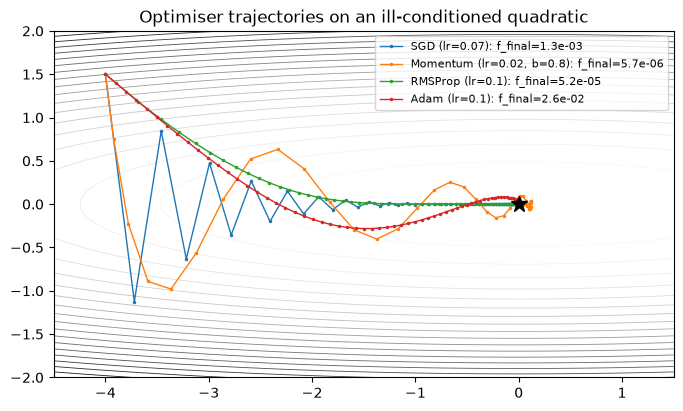

In [15]:
def run_quadratic(opt, steps=60, theta0=(-4.0, 1.5)):
    theta = np.array(theta0); path = [theta.copy()]
    for _ in range(steps):
        grad = np.array([theta[0], 25 * theta[1]])
        opt.step([theta], [grad]); path.append(theta.copy())
    return np.array(path)

opts_2d = {"SGD (lr=0.07)": SGD(0.07), "Momentum (lr=0.02, b=0.8)": Momentum(0.02, 0.8),
           "RMSProp (lr=0.1)": RMSProp(0.1), "Adam (lr=0.1)": Adam(0.1)}
t1, t2 = np.meshgrid(np.linspace(-4.5, 1.5, 200), np.linspace(-2, 2, 200))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.contour(t1, t2, 0.5 * (t1 ** 2 + 25 * t2 ** 2), levels=20, cmap="Greys", linewidths=0.6)
for name, opt in opts_2d.items():
    path = run_quadratic(opt)
    ax.plot(path[:, 0], path[:, 1], ".-", ms=3, lw=1, label=f"{name}: f_final={0.5*(path[-1,0]**2+25*path[-1,1]**2):.1e}")
ax.plot(0, 0, "k*", ms=12); ax.legend(fontsize=8); ax.set_title("Optimiser trajectories on an ill-conditioned quadratic")
plt.show()

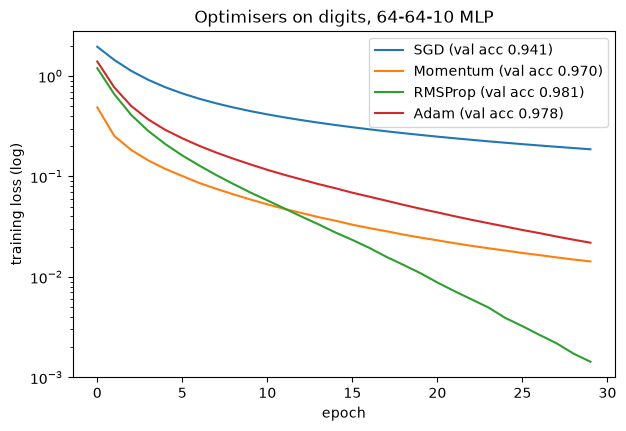

In [16]:
# Compare the optimisers on the digits network (same initialisation for all)
configs = {"SGD": lambda: SGD(0.01), "Momentum": lambda: Momentum(0.01, 0.9),
           "RMSProp": lambda: RMSProp(0.001), "Adam": lambda: Adam(0.001)}
fig, ax = plt.subplots()
for name, make in configs.items():
    net_o = MLP([64, 64, 10], act="relu", init="he", seed=0)
    h_o = train(net_o, make(), Xd_tr_s, yd_tr, Xd_val_s, yd_val, epochs=30, batch_size=32)
    ax.semilogy(h_o["train_loss"], label=f"{name} (val acc {h_o['val_acc'][-1]:.3f})")
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (log)"); ax.set_title("Optimisers on digits, 64-64-10 MLP")
ax.legend(); plt.show()

On the quadratic, SGD's step size is limited by the stiff direction ($\eta < 2/25$), so it zig-zags there and crawls along the flat one; momentum and RMSProp fix this in different ways (averaging vs per-coordinate rescaling). Adam's normalised steps are roughly of size $\eta$ regardless of the gradient magnitude, so with a constant learning rate it hovers around the optimum rather than converging exactly — one reason learning-rate decay is used in practice.

On digits, with a small learning rate plain SGD is slow; momentum gives roughly the $1/(1-\beta)$ speed-up predicted above; adaptive methods (RMSProp, Adam) make fast progress with their default learning rates. Keep in mind that fast *training* loss decrease is not the same as best *generalisation* — well-tuned SGD with momentum often generalises as well as or better than Adam on large vision tasks (Wilson et al., 2017).

## 11. Overfitting: L2 regularisation and early stopping

A network with many more parameters than training points can memorise the data. We make overfitting visible by training a wide network ($\approx 83$k parameters) on only 150 digits, of which about 20% have **randomly corrupted labels** (a common stress test: memorising noise is exactly what hurts generalisation).

**L2 regularisation (weight decay).** Adding $\frac\lambda2\sum_\ell\|W^{(\ell)}\|_F^2$ changes the SGD update to
$$W \leftarrow (1 - \eta\lambda)W - \eta\nabla_W\mathcal L_{\text{data}},$$
i.e. weights decay geometrically towards 0 unless the data push back. The Bayesian reading is a MAP estimate under a Gaussian prior $W_{ij}\sim\mathcal N(0, 1/\lambda)$. (Biases are usually not penalised.)

**Early stopping.** Monitor validation loss and keep the parameters from the best epoch; stop after `patience` epochs without improvement. For a quadratic loss and gradient descent from $\theta_0 = 0$, stopping after $t$ steps with step size $\eta$ behaves like L2 regularisation with $\lambda \approx 1/(\eta t)$ (Goodfellow et al., §7.8) — the number of iterations is itself a regularisation hyperparameter.

corrupted labels: 27 / 150


no regularisation  train acc 1.000  val acc 0.770  test acc 0.793


L2 (lambda=1e-2)   train acc 1.000  val acc 0.811  test acc 0.811


early stopping     train acc 1.000  val acc 0.770  test acc 0.796 (stopped at 27, best 17)


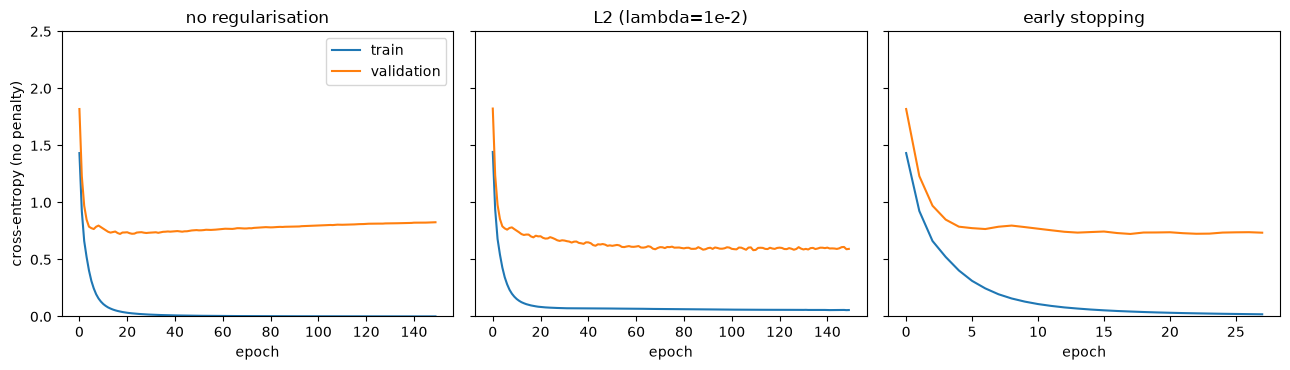

In [17]:
small_idx = rng.choice(len(yd_tr), size=150, replace=False)
Xs_tr, ys_tr = Xd_tr_s[small_idx], yd_tr[small_idx].copy()
flip = rng.random(len(ys_tr)) < 0.2                      # corrupt ~20% of the labels
ys_tr[flip] = rng.integers(0, 10, flip.sum())
print(f"corrupted labels: {(ys_tr != yd_tr[small_idx]).sum()} / {len(ys_tr)}")

results = {}
for name, l2, patience in [("no regularisation", 0.0, None), ("L2 (lambda=1e-2)", 1e-2, None),
                            ("early stopping", 0.0, 10)]:
    net_r = MLP([64, 256, 256, 10], act="relu", init="he", l2=l2, seed=0)
    h_r = train(net_r, Adam(0.001), Xs_tr, ys_tr, Xd_val_s, yd_val, epochs=150, batch_size=32, patience=patience)
    results[name] = (net_r, h_r)
    extra = f" (stopped at {h_r['stopped_epoch']}, best {h_r['best_epoch']})" if "stopped_epoch" in h_r else ""
    print(f"{name:18s} train acc {net_r.score(Xs_tr, ys_tr):.3f}  val acc {net_r.score(Xd_val_s, yd_val):.3f}  "
          f"test acc {net_r.score(Xd_te_s, yd_te):.3f}{extra}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (name, (_, h_r)) in zip(axes, results.items()):
    ax.plot(h_r["train_loss"], label="train"); ax.plot(h_r["val_loss"], label="validation")
    ax.set_title(name); ax.set_xlabel("epoch"); ax.set_ylim(0, 2.5)
axes[0].set_ylabel("cross-entropy (no penalty)"); axes[0].legend()
plt.tight_layout(); plt.show()

Without regularisation the training loss goes to (almost) zero — the network memorises even the corrupted labels — while the validation loss reaches a minimum early and then climbs: the classic overfitting signature. The L2 penalty prevents the training loss from reaching zero and yields a lower, flatter validation curve, and early stopping simply returns the weights from the minimum of the validation curve. Exact numbers vary with the random seed; with such a small validation set, differences of 1–2% in accuracy are within noise.

## 12. Comparison with scikit-learn's `MLPClassifier`

`MLPClassifier` implements exactly the model we built: fully connected layers, ReLU/tanh/logistic activations, softmax cross-entropy, L2 penalty `alpha` (applied as $\frac{\alpha}{2m}\|W\|^2$ — note the scaling by the number of samples), Glorot-style initialisation, and SGD/Adam/L-BFGS solvers with optional early stopping.

scratch MLP : test acc 0.978  (0.5s)
sklearn MLP : test acc 0.971  (0.7s)
agreement between the two models' test predictions: 0.9777777777777777


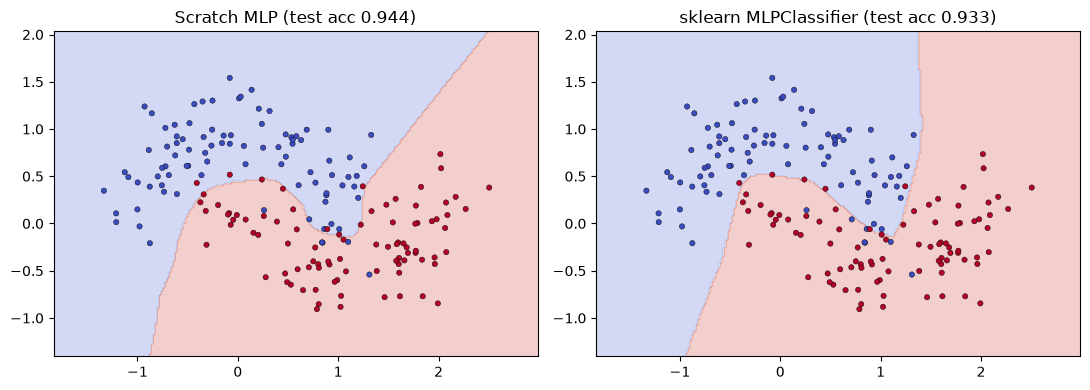

In [18]:
Xd_trval_s = np.vstack([Xd_tr_s, Xd_val_s]); yd_trval = np.r_[yd_tr, yd_val]

t0 = time.time()
ours = MLP([64, 64, 10], act="relu", init="he", l2=1e-4, seed=0)
train(ours, Adam(0.001), Xd_trval_s, yd_trval, epochs=60, batch_size=32)
t_ours = time.time() - t0

t0 = time.time()
skm = MLPClassifier(hidden_layer_sizes=(64,), activation="relu", solver="adam", alpha=1e-4,
                    batch_size=32, learning_rate_init=0.001, max_iter=60, random_state=0).fit(Xd_trval_s, yd_trval)
t_sk = time.time() - t0

print(f"scratch MLP : test acc {ours.score(Xd_te_s, yd_te):.3f}  ({t_ours:.1f}s)")
print(f"sklearn MLP : test acc {skm.score(Xd_te_s, yd_te):.3f}  ({t_sk:.1f}s)")
print("agreement between the two models' test predictions:", (ours.predict(Xd_te_s) == skm.predict(Xd_te_s)).mean())

m_moon = MLPClassifier(hidden_layer_sizes=(32, 32), max_iter=1000, random_state=0).fit(Xm_tr, ym_tr)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_boundary(moon_net.predict, Xm_te, ym_te, ax=axes[0], title=f"Scratch MLP (test acc {moon_net.score(Xm_te, ym_te):.3f})")
plot_boundary(m_moon.predict, Xm_te, ym_te, ax=axes[1], title=f"sklearn MLPClassifier (test acc {m_moon.score(Xm_te, ym_te):.3f})")
plt.tight_layout(); plt.show()

## 13. Pitfalls & practical tips

- **Always gradient-check new layers** on a tiny float64 network before training at scale. A model that "learns a bit" can still have a wrong gradient.
- **Check the initial loss** ($\approx\log K$ for $K$ balanced classes) and try to **overfit a tiny batch** (e.g. 20 examples) to ~zero loss; if you cannot, there is a bug or the model/learning rate is wrong.
- **Standardise inputs.** Unscaled features make the loss surface ill-conditioned and interact badly with initialisation. Fit the scaler on the training split only.
- **Use a numerically stable softmax/log-softmax.** Never compute `log(softmax(z))` naively.
- **Learning rate is the most important hyperparameter.** Sweep it on a log scale ($10^{-4}\dots10^{-1}$). Divergence (loss becomes `nan`) usually means it is too large.
- **Match initialisation to activation**: He for ReLU-family, Xavier for tanh/sigmoid. Never initialise all weights to the same value.
- **Dead ReLUs**: a unit whose pre-activation is negative for all inputs gets zero gradient forever. Causes: too large a learning rate, bad initialisation, large negative bias. Leaky ReLU or a lower learning rate helps.
- **Sigmoid hidden units** saturate and are not zero-centred; prefer ReLU/tanh in hidden layers.
- **Shuffle every epoch** and keep the validation/test sets untouched by preprocessing fits and early-stopping decisions (report test performance only once).
- **Regularisation hyperparameters interact** with the optimiser: weight decay in Adam is not the same as L2 in the loss (see AdamW, Loshchilov & Hutter, 2019).

## 14. Exercises

**Exercise 1 (pen and paper, perceptron).** (a) Show that the perceptron update never increases $\|\mathbf w - \alpha\mathbf w^\star\|^2$ for sufficiently large $\alpha > 0$ on a mistake, and use this to give an alternative proof of the convergence theorem. (b) Construct a 2-D separable dataset with margin $\gamma$ and radius $R$ on which the perceptron makes $\Theta(R^2/\gamma^2)$ mistakes.

**Exercise 2 (pen and paper, backprop).** For a single hidden layer network with tanh activation and **mean squared error** output $\mathcal L = \frac{1}{2m}\|\,\tanh(XW_1 + \mathbf 1\mathbf b_1)W_2 + \mathbf 1\mathbf b_2 - Y\|_F^2$, derive $\partial\mathcal L/\partial W_1$, $\partial\mathcal L/\partial\mathbf b_1$, $\partial\mathcal L/\partial W_2$, $\partial\mathcal L/\partial\mathbf b_2$ in matrix form. Verify dimensions. Also derive the Jacobian of softmax, $\partial p_k/\partial z_j = p_k(\mathbb 1[k=j] - p_j)$, and use it to re-derive $\bar{\mathbf z} = \mathbf p - \mathbf y$.

**Exercise 3 (coding, regression head).** Extend the `MLP` class to support regression with an identity output and MSE loss (the code cell below gives a starter). Gradient-check it, then fit $y = \sin(3x) + \varepsilon$ on $[-2, 2]$ and plot the fit for widths 4, 16, 64.

**Exercise 4 (coding, initialisation for tanh).** Repeat the activation-statistics experiment of Section 9 with **tanh** activations and the four initialisation schemes. Which scheme keeps activations away from both 0 and saturation? Plot histograms of the activations at layer 5.

**Exercise 5 (coding, Nesterov and AdamW).** Implement Nesterov momentum ($v_t = \beta v_{t-1} + \nabla\mathcal L(\theta_{t-1} - \eta\beta v_{t-1})$; use the common reparametrised form) and AdamW (decoupled weight decay $\theta \leftarrow \theta - \eta\lambda\theta$ applied outside the adaptive step). Compare with Section 10 on the digits task.

**Exercise 6 (coding, dropout).** Add inverted dropout with keep probability $q$ to the hidden layers (scale kept activations by $1/q$ during training, do nothing at test time). Explain why the backward pass must reuse the same mask. Repeat the 150-example overfitting experiment of Section 11 with $q\in\{1.0, 0.8, 0.5\}$.

In [19]:
# Exercise 3 starter: regression MLP with MSE loss
class MLPRegressorScratch(MLP):
    def loss(self, X, y):
        # TODO: return 0.5 * mean squared error (+ L2 penalty) using self.forward(X)[0][:, 0]
        pass

    def loss_and_grads(self, X, y):
        # TODO: forward pass, loss, and backprop. Hint: dL/dZ^(L) = (Z^(L)[:, 0] - y)[:, None] / m
        pass

# Usage once implemented:
# reg = MLPRegressorScratch([1, 16, 1], act="tanh", init="xavier")
# g_an = reg.loss_and_grads(Xr, yr)[1]; print(rel_error(g_an, numerical_grads(reg, Xr, yr)))

In [20]:
# Exercise 5 starter: AdamW optimiser
class AdamW(Adam):
    def __init__(self, lr=0.001, weight_decay=1e-2, **kw):
        super().__init__(lr=lr, **kw)
        self.wd = weight_decay

    def step(self, params, grads):
        # TODO: apply decoupled weight decay p -= lr * wd * p (weights only), then the Adam step
        pass

In [21]:
# Exercise 6 starter: inverted dropout forward/backward helpers
def dropout_forward(A, keep_prob, rng):
    # TODO: sample a mask with P(keep) = keep_prob, return (A * mask / keep_prob, mask)
    pass

def dropout_backward(dA, mask, keep_prob):
    # TODO: return the gradient w.r.t. the input of the dropout layer
    pass

## 15. Summary

- The perceptron learns any linearly separable dataset in at most $(R/\gamma)^2$ mistakes, but it cannot represent XOR; stacking nonlinear layers fixes this.
- Nonlinear activations are essential; ReLU avoids saturation, sigmoid/tanh saturate and have derivatives $\le 1/4$ and $\le 1$, contributing to vanishing gradients.
- One hidden layer is a universal approximator, but existence of weights says nothing about optimisation or generalisation; depth can be exponentially more parameter-efficient.
- Backpropagation is reverse-mode automatic differentiation on the computational graph. For an affine layer: $\bar W = A^\top\Delta$, $\bar{\mathbf b} = \mathbf 1^\top\Delta$, $\bar A = \Delta W^\top$; for softmax cross-entropy: $\Delta = (P - Y)/m$.
- Always validate gradients numerically with central differences and relative error.
- Initialisation scale should preserve activation/gradient variance across layers: Xavier $2/(n_{\text{in}}+n_{\text{out}})$, He $2/n_{\text{in}}$.
- Momentum accelerates along consistent directions; RMSProp/Adam adapt per-parameter step sizes; Adam adds bias correction.
- Wide networks overfit small datasets; L2 weight decay and early stopping are simple, effective regularisers. Our from-scratch MLP matches scikit-learn's `MLPClassifier`.

## Further reading

- Goodfellow, Bengio & Courville, *Deep Learning* (2016): Ch. 6 (deep feedforward networks, back-propagation), Ch. 7 (regularisation, early stopping §7.8), Ch. 8 (optimisation, momentum, Adam).
- Bishop, *Pattern Recognition and Machine Learning* (2006): Ch. 5 (neural networks, error backpropagation, §5.3).
- Murphy, *Probabilistic Machine Learning: An Introduction* (2022): Ch. 13 (neural networks for tabular data), Ch. 8 (optimisation).
- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning* (2009): Ch. 11 (neural networks).
- James et al., *An Introduction to Statistical Learning (ISLP)* (2023): Ch. 10 (deep learning).
- Géron, *Hands-On Machine Learning* (3rd ed.): Ch. 10–11.
- Rosenblatt (1958), "The perceptron: a probabilistic model..."; Novikoff (1962), convergence proof; Minsky & Papert (1969), *Perceptrons*.
- Rumelhart, Hinton & Williams (1986), "Learning representations by back-propagating errors", *Nature*.
- Cybenko (1989); Hornik (1991); Leshno et al. (1993) — universal approximation.
- Glorot & Bengio (2010), "Understanding the difficulty of training deep feedforward neural networks"; He et al. (2015), "Delving deep into rectifiers".
- Kingma & Ba (2015), "Adam: A method for stochastic optimization"; Loshchilov & Hutter (2019), "Decoupled weight decay regularization".